In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.metrics import r2_score

---
# <u>Load Dataset</u>

In [21]:
# print(sns.get_dataset_names())
diamond_data = sns.load_dataset('diamonds')
diamond_data.info() # no missing values
diamond_data["cut"].nunique() # 5
diamond_data["color"].nunique() # 7
diamond_data["clarity"].nunique() # 8
diamond_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


---
# <u>Train Test Split</u>

In [22]:
X = diamond_data.drop(columns = ["price"])
y = diamond_data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

---
# <u>Feature Encoding and Scaling</u>

In [23]:
# We will use a new concept of ColumnTransformer to encode categorical columns and scaling together in one go

# 1. get numerical and categorical columns
num_cols = X_train.select_dtypes(include = "number").columns
cat_cols = X_train.select_dtypes(include = "category").columns

# 2. make the preprocessor
preprocessor = ColumnTransformer(
    transformers = [
        # (name, transformer_function, list_of_columns)
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(sparse_output = False, handle_unknown = "ignore"), cat_cols)
    ]
)

# 3. make the output as a df
preprocessor.set_output(transform="pandas")

# 4. Run it on the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_train.head()

,num__carat,num__depth,num__table,num__x,num__y,num__z,cat__cut_Fair,cat__cut_Good,cat__cut_Ideal,cat__cut_Premium,...,cat__color_I,cat__color_J,cat__clarity_I1,cat__clarity_IF,cat__clarity_SI1,cat__clarity_SI2,cat__clarity_VS1,cat__clarity_VS2,cat__clarity_VVS1,cat__clarity_VVS2
26546,2.560056,-2.550748,2.933861,2.229450,2.138209,1.738207,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9159,0.447392,-1.220426,1.139575,0.747550,0.656710,0.537733,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
14131,0.637532,0.529996,0.242432,0.765404,0.700284,0.791951,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15757,1.482597,-0.170173,3.382432,1.318885,1.249310,1.243894,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
24632,1.524851,0.249928,-0.206140,1.372448,1.380030,1.399249,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


---
# <u>Create model, Train and Predict</u>

In [6]:
# 1. Base Tree for Alphas (Stays the same)
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
reduced_ccp_alphas = ccp_alphas[::1000]

# 2. Build Pipeline
steps = [
    ("rfr", RandomForestRegressor(random_state=42))
]
pipeline = Pipeline(steps)

# 3. FAST PARAMETER GRID
param_grid = {
    "rfr__n_estimators" : [50, 100, 150],
    "rfr__criterion" : ["squared_error"],
    "rfr__max_depth" : [4, 6, 8, 10],
    "rfr__min_samples_split" : [2, 5, 10],
    "rfr__ccp_alpha" : reduced_ccp_alphas,
    "rfr__bootstrap" : [True],
    "rfr__oob_score" : [True]
}

# 4. LIGHTWEIGHT RANDOMIZED SEARCH
rfr_model_cv = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=15,       
    cv=3,            
    random_state=42,  
    n_jobs=-1         
)

# 5. Fit and Predict
rfr_model_cv.fit(X_train, y_train)
y_train_pred = rfr_model_cv.predict(X_train)
y_test_pred = rfr_model_cv.predict(X_test)


# 6. Output
print("For Random Forest Regressor (hyperparameter tuning) :-\n")
print("Best Parameters : ", rfr_model_cv.best_params_)
print("\nTrain Accuracy (R2 Score) : ", r2_score(y_train, y_train_pred))
print("\nTest Accuracy (R2 Score) : ", r2_score(y_test, y_test_pred))

For Random Forest Regressor (hyperparameter tuning) :-

Best Parameters :  {'rfr__oob_score': True, 'rfr__n_estimators': 100, 'rfr__min_samples_split': 5, 'rfr__max_depth': 10, 'rfr__criterion': 'squared_error', 'rfr__ccp_alpha': np.float64(0.47313372883436355), 'rfr__bootstrap': True}

Train Accuracy (R2 Score) :  0.974667994147435

Test Accuracy (R2 Score) :  0.9719679700266468


---
## <u>Plot Tree</u>

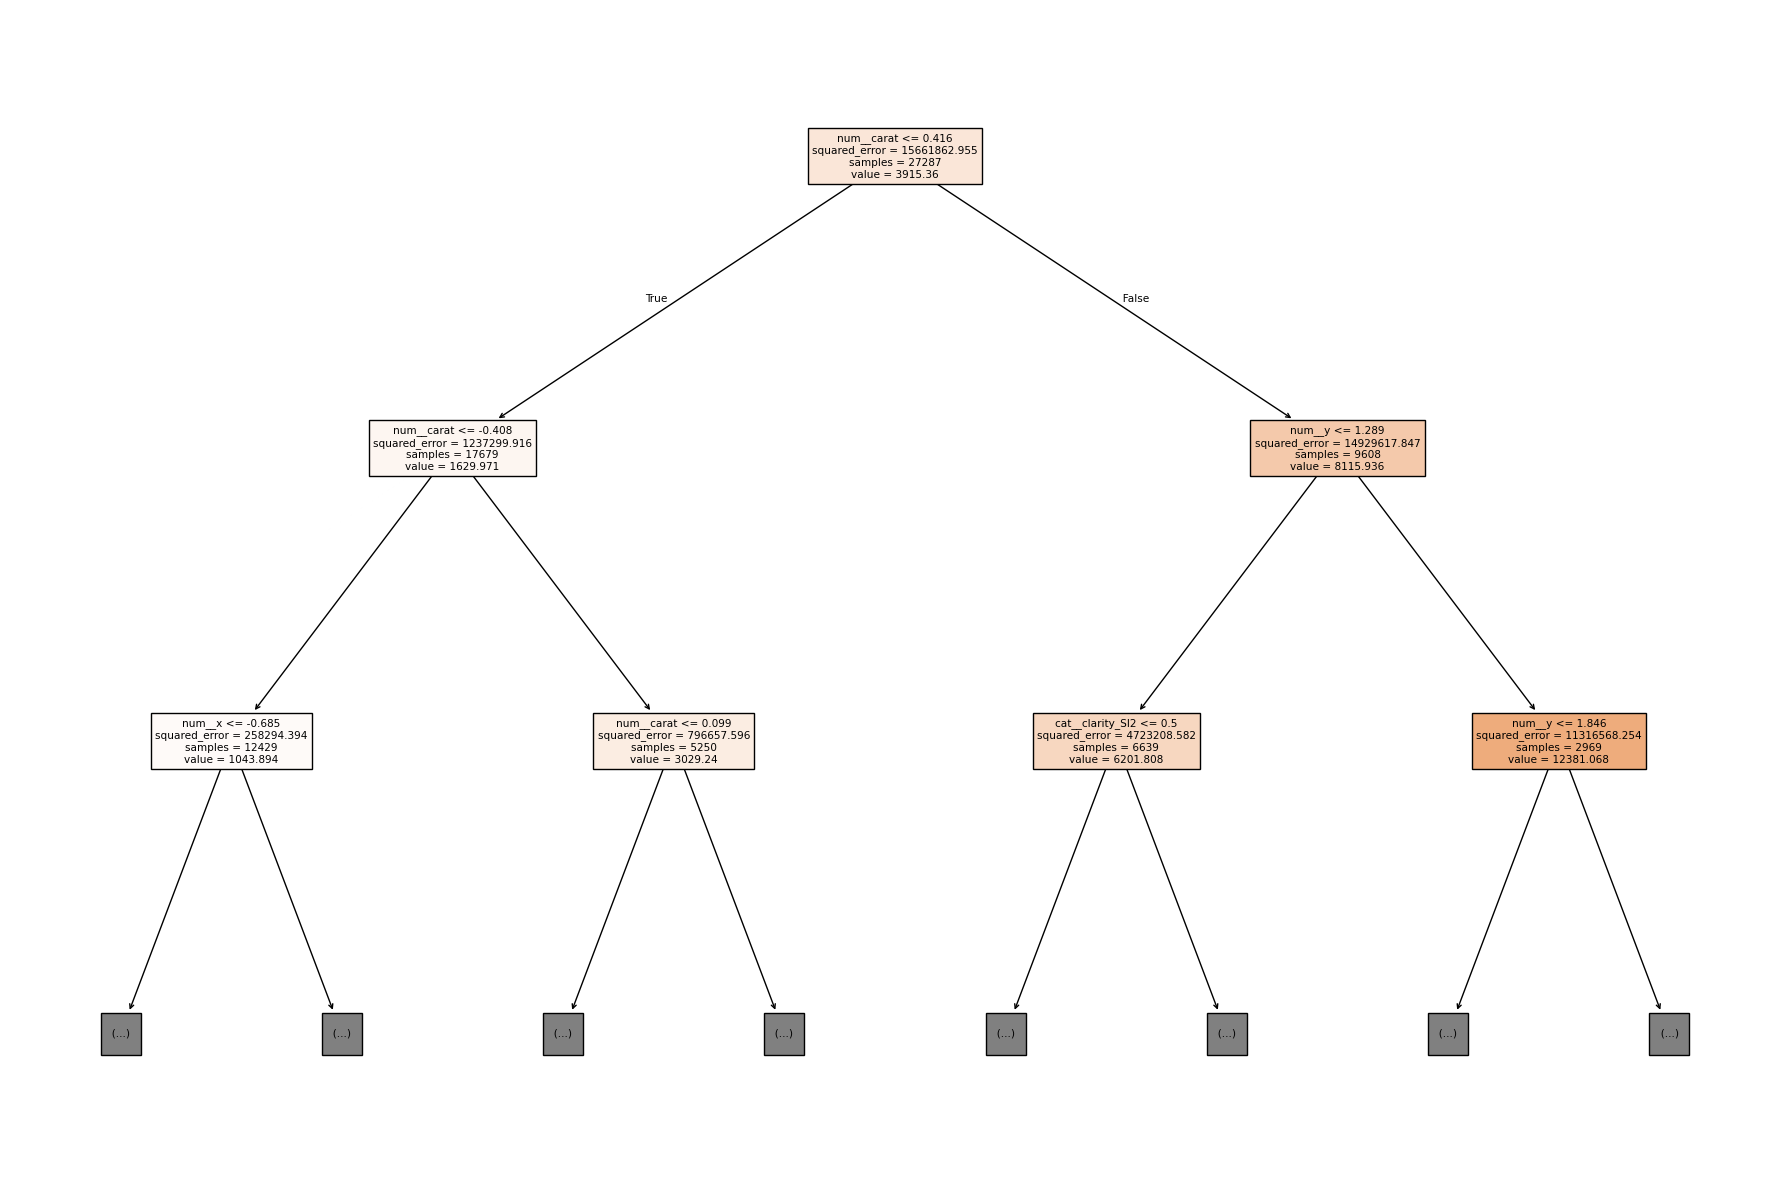

In [18]:
plt.figure(figsize=(18,12))

# 1. Extract the components cleanly
best_pipeline = rfr_model_cv.best_estimator_
best_model = best_pipeline.named_steps["rfr"]

# 2. Pluck out the very first estimator tree from the forest
single_tree = best_model.estimators_[0]

# 3. FIX: Get the actual one-hot encoded column layout from your preprocessor
feature_names = preprocessor.get_feature_names_out()

plot_tree(
    single_tree,
    filled=True,
    feature_names = feature_names,
    # class_names = ["price"], # dont use this as class_names is only classification
    max_depth = 2 
)

plt.tight_layout()
plt.show()

---
## <u>Bagging Classifier Comparison</u>

In [25]:
base_model = DecisionTreeRegressor(random_state = 42)
bagging_model = BaggingRegressor(
    base_model,
    n_estimators = 101
)

bagging_model.fit(X_train, y_train)
y_train_pred = bagging_model.predict(X_train)
y_test_pred = bagging_model.predict(X_test)


print("For Bagging Regressor + Decision Tree Regressor :-\n")
print("\nTrain Accuracy (R2 Score) : ", r2_score(y_train, y_train_pred))
print("\nTest Accuracy (R2 Score) : ", r2_score(y_test, y_test_pred))

For Bagging Regressor + Decision Tree Regressor :-


Train Accuracy (R2 Score) :  0.9973391241640764

Test Accuracy (R2 Score) :  0.9807516630291941


---
## Key Findings

- By default, the BaggingRegressor uses deep, unconstrained trees (max_depth=None, ccp_alpha=0.0) that grow until perfectly pure, aggressively memorizing the training data to hit a high 0.997 $R^2$ score.
- Despite individual trees overfitting, bagging trains each one on a different random subset of rows (bootstrap samples). Averaging their predictions cancels out this high variance, rescuing the test score to 0.980.
- The tuned Random Forest introduces Feature Subspace Sampling (random column subsets at splits) alongside strict constraints (max_depth=10, ccp_alpha=0.473). This blocks overfitting, resulting in an incredibly stable 0.3% gap between train (0.975) and test (0.972).
- The untuned Bagging model relies on the brute-force power of massive, deep trees for a minor test boost. The tuned Random Forest intentionally trades a negligible fraction of test accuracy for a highly compact, optimized, and robust architecture that guarantees reliability on unseen data.